# Live Evaluation — Train on JSONL, Test on New DB Candles

**Goal:** The ultimate honest test. Train the model on ALL `latest_features.jsonl` data,
then evaluate on **completely new candles** from `collection.db` that arrived after
the newest training timestamp.

**Why this matters:** All previous notebooks used train/test splits from the same dataset.
This notebook tests on data from a **different time period** — the most realistic evaluation
possible without live trading.

**Pipeline:**
1. Train LogisticRegression on ALL features from `latest_features.jsonl`
2. Find the newest candle timestamp in the training data
3. Query `collection.db` for candles AFTER that timestamp
4. Compute features for new candles using `compute_all`
5. Run predictions and evaluate — accuracy, PnL, confidence calibration

In [1]:
import json
import random
import sqlite3
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from evaluator import Evaluator
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from technicals import CandleRecord, IndicatorSnapshot, compute_all
from tqdm import tqdm

random.seed(42)
np.random.seed(42)

FEATURES_PATH = Path("../data/latest_features.jsonl")
DB_PATH = Path("../data/collection.db")
LR_FEATURES_PATH = Path("../data/optimal_features_lr.json")
MAX_BID = 0.85
WARM_UP = 21

## 1. Train on ALL latest_features.jsonl

**What:** Load the entire feature dataset and train LogisticRegression on ALL of it.
No train/test split — the test set is completely new candles from `collection.db`
that arrived after the newest timestamp in the training data.

In [2]:
# Train on ALL latest_features.jsonl
rows = []
with open(FEATURES_PATH) as f:
    for line in f:
        rows.append(json.loads(line))

df_train = pd.DataFrame(rows)
df_train["target"] = (df_train["outcome"] == "UP").astype(int)
# Load optimal LR features
with open(LR_FEATURES_PATH) as _f:
    feat_cols = sorted(json.load(_f)["features"])
print(f"Using {len(feat_cols)} optimal LR features from {LR_FEATURES_PATH.name}")
df_train[feat_cols] = df_train[feat_cols].fillna(0.0)

scaler = StandardScaler()
X_train = scaler.fit_transform(df_train[feat_cols].values)
y_train = df_train["target"].values

model = LogisticRegression(max_iter=1000, random_state=42)
model.fit(X_train, y_train)

# Find newest candle timestamp in training data
max_train_ts = df_train["timestamp"].max()
print(f"Trained on {df_train['candle_id'].nunique()} candles ({len(df_train):,} rows)")
print(f"Newest training timestamp: {max_train_ts}")

Using 35 optimal LR features from optimal_features_lr.json
Trained on 1376 candles (66,153 rows)
Newest training timestamp: 1775698199.5841138


## 2. Load new candles from DB and compute features

**What:** Query `collection.db` for candles whose `start_time` is after the newest training
timestamp. Load WARM_UP prior candles for indicator computation context, then run
`compute_all` on each new candle's snapshots to produce the evaluation DataFrame.

In [3]:
# Load candles newer than training data from DB
conn = sqlite3.connect(str(DB_PATH))
candles_df = pd.read_sql(
    f"SELECT * FROM candles WHERE start_time > {max_train_ts} ORDER BY start_time",
    conn,
)
snaps_df = (
    pd.read_sql(
        "SELECT * FROM snapshots WHERE candle_id IN ({}) ORDER BY candle_id, timestamp".format(
            ",".join(f"'{cid}'" for cid in candles_df["candle_id"])
        ),
        conn,
    )
    if len(candles_df) > 0
    else pd.DataFrame()
)

# Also load WARM_UP candles before the cutoff for indicator computation
prior_candles_df = pd.read_sql(
    f"SELECT * FROM candles WHERE start_time <= {max_train_ts} ORDER BY start_time DESC LIMIT {WARM_UP}",
    conn,
)
conn.close()

prior_candles_df = prior_candles_df.sort_values("start_time")

# Build prior candles for warm-up
prior_candles = []
for _, cr in prior_candles_df.iterrows():
    prior_candles.append(
        CandleRecord(
            candle_id=cr["candle_id"],
            start_time=cr["start_time"],
            end_time=cr["end_time"],
            open=cr["open"],
            high=cr["high"],
            low=cr["low"],
            close=cr["close"],
            volume=cr["volume"],
            outcome=cr["outcome"],
            final_ret=cr["final_ret"],
        )
    )

# Compute features for new candles
all_rows = []
for _, cr in tqdm(candles_df.iterrows(), total=len(candles_df), desc="Computing features"):
    cid = cr["candle_id"]
    candle = CandleRecord(
        candle_id=cid,
        start_time=cr["start_time"],
        end_time=cr["end_time"],
        open=cr["open"],
        high=cr["high"],
        low=cr["low"],
        close=cr["close"],
        volume=cr["volume"],
        outcome=cr["outcome"],
        final_ret=cr["final_ret"],
    )

    snap_rows = snaps_df[snaps_df["candle_id"] == cid]
    if len(snap_rows) < 5:
        prior_candles.append(candle)
        continue

    snapshots = []
    for _, s in snap_rows.iterrows():
        ob = json.loads(s["orderbook_json"])
        snapshots.append(
            IndicatorSnapshot(
                candle_id=cid,
                timestamp=s["timestamp"],
                elapsed_pct=s["elapsed_pct"],
                btc_price=s["btc_price"],
                btc_bid=s["btc_bid"],
                btc_ask=s["btc_ask"],
                up_bids=[ob["up_bids"][0]] if ob.get("up_bids") else [],
                up_asks=[ob["up_asks"][0]] if ob.get("up_asks") else [],
                down_bids=[ob["down_bids"][0]] if ob.get("down_bids") else [],
                down_asks=[ob["down_asks"][0]] if ob.get("down_asks") else [],
                market_volume=s["market_volume"],
            )
        )

    for si in range(len(snapshots)):
        indicators = compute_all(prior_candles, candle.open, snapshots[: si + 1])
        snap = snapshots[si]
        row = {
            "candle_id": cid,
            "timestamp": snap.timestamp,
            "elapsed_pct": snap.elapsed_pct,
            "btc_price": snap.btc_price,
            "up_best_bid": snap.up_bids[0][0] if snap.up_bids else None,
            "up_best_ask": snap.up_asks[0][0] if snap.up_asks else None,
            "up_bid_depth": snap.up_bids[0][1] if snap.up_bids else None,
            "up_ask_depth": snap.up_asks[0][1] if snap.up_asks else None,
            "down_best_bid": snap.down_bids[0][0] if snap.down_bids else None,
            "down_best_ask": snap.down_asks[0][0] if snap.down_asks else None,
            "down_bid_depth": snap.down_bids[0][1] if snap.down_bids else None,
            "down_ask_depth": snap.down_asks[0][1] if snap.down_asks else None,
            "market_volume": snap.market_volume,
            **indicators,
            "outcome": candle.outcome,
        }
        all_rows.append(row)
    prior_candles.append(candle)

df_new = pd.DataFrame(all_rows)
df_new["target"] = (df_new["outcome"] == "UP").astype(int)
df_new["winner_bid"] = df_new[["up_best_bid", "down_best_bid"]].max(axis=1)

# Ensure feat_cols from training are present (fill missing with 0)
for col in feat_cols:
    if col not in df_new.columns:
        df_new[col] = 0.0
df_new[feat_cols] = df_new[feat_cols].fillna(0.0)

# Build new_candles list for simulation cells
new_candles = []
for cid in df_new["candle_id"].unique():
    outcome = df_new[df_new["candle_id"] == cid]["outcome"].iloc[0]
    new_candles.append({"candle": type("C", (), {"candle_id": cid, "outcome": outcome})(), "snapshots": []})

print(f"\nNew candles for evaluation: {df_new['candle_id'].nunique()}")
print(f"Rows: {len(df_new):,}")
if len(df_new) == 0:
    print("WARNING: No new candles found. Run the collector longer or rebuild features with older data.")

Computing features: 100%|██████████| 137/137 [00:01<00:00, 108.90it/s]



New candles for evaluation: 137
Rows: 6,502


## 3. Evaluate — all new data

**What:** Apply the trained model to the entire new dataset from DB. No filtering.

=== All new data (unfiltered) ===
  Regression:      MSE=0.1663  R²=33.4%  MAE=0.3350
  Classification:  Accuracy=74.1%  Precision=77.4%  Recall=70.7%  F1=73.9%
  Samples:         6502 (UP=3370, DOWN=3132)


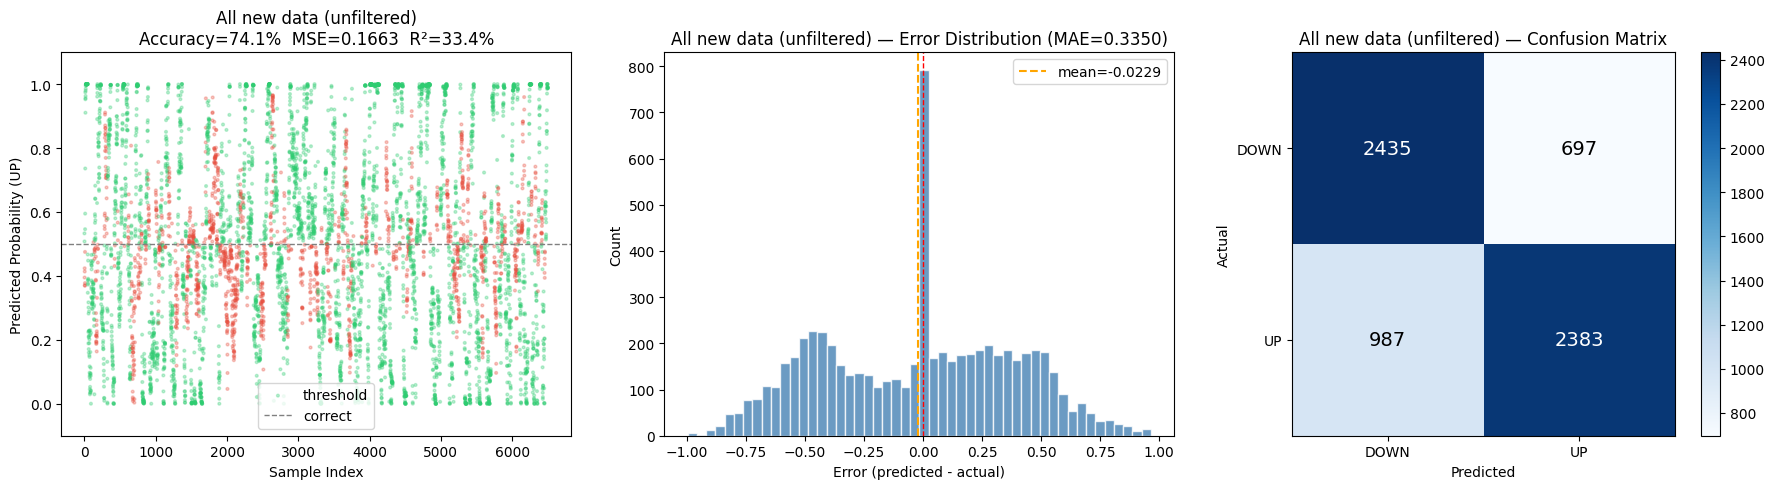

In [4]:
# Scale new data using the SAME scaler fit on training data
X_new = scaler.transform(df_new[feat_cols].values)
y_new = df_new["target"].values
asks_new = df_new["up_best_ask"].values

y_prob_new = model.predict_proba(X_new)[:, 1]
y_pred_new = model.predict(X_new)

ev_all = Evaluator(y_new, y_pred_new, y_prob_new, title="All new data (unfiltered)")
ev_all.full_report()

## 4. Evaluate — trading window only

**What:** Filter to the optimal trading window (`elapsed >= 30%`, `winner_bid <= 0.85`) and evaluate.

=== Trading window (e>=30%, bid<=0.85) ===
  Regression:      MSE=0.2056  R²=17.5%  MAE=0.4133
  Classification:  Accuracy=68.5%  Precision=75.0%  Recall=60.7%  F1=67.1%
  Samples:         2776 (UP=1469, DOWN=1307)


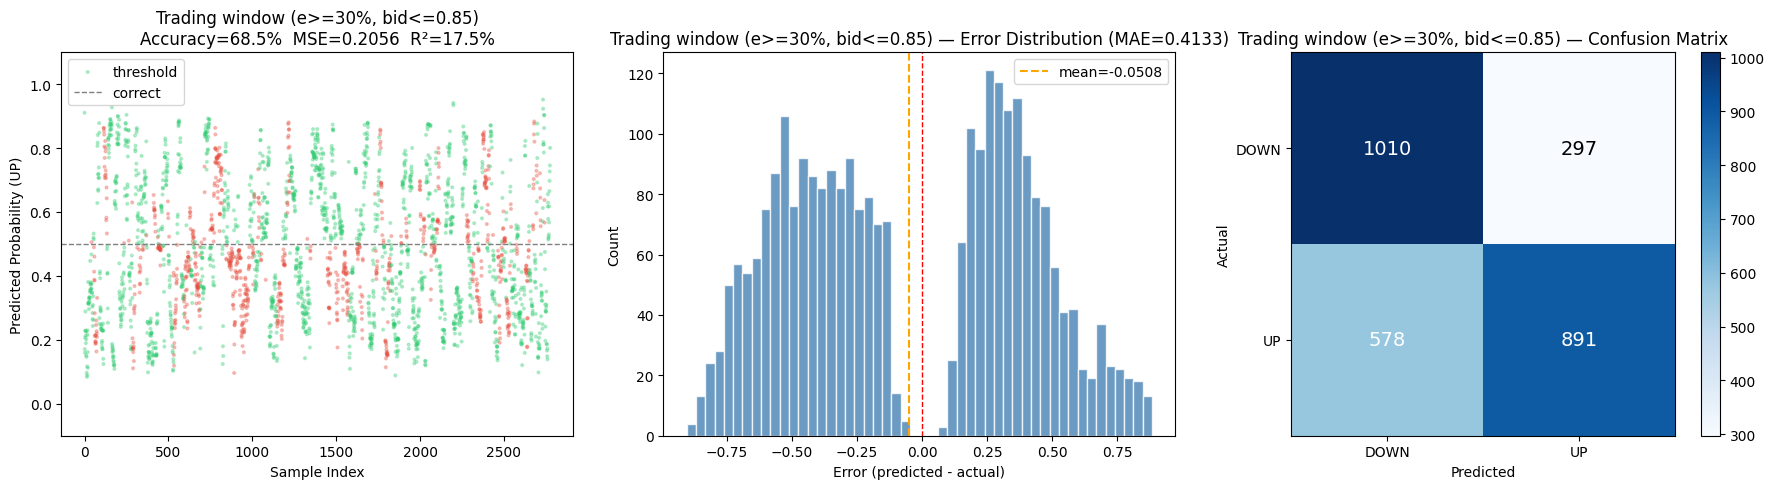


Filtered: 2,776 snapshots from 127 candles


In [5]:
# Filtered evaluation
mask = (df_new["elapsed_pct"] >= 0.30) & (df_new["winner_bid"] <= MAX_BID)
df_filtered = df_new[mask]

if len(df_filtered) > 0:
    X_filt = scaler.transform(df_filtered[feat_cols].values)
    y_filt = df_filtered["target"].values
    asks_filt = df_filtered["up_best_ask"].values

    y_prob_filt = model.predict_proba(X_filt)[:, 1]
    y_pred_filt = model.predict(X_filt)

    ev_filt = Evaluator(y_filt, y_pred_filt, y_prob_filt, title=f"Trading window (e>=30%, bid<={MAX_BID})")
    ev_filt.full_report()

    print(f"\nFiltered: {len(df_filtered):,} snapshots from {df_filtered['candle_id'].nunique()} candles")
else:
    print("No snapshots match the trading window filter")

## 6. PnL simulation — one bet per candle

**What:** Simulate the recommended strategy: **one bet per candle** using the 3-consecutive trigger (start counting after 5% elapsed). Flat $10 bets.

**Why one bet per candle?** Betting on every snapshot is catastrophic (see notebook 9 analysis) — ~35 correlated bets per candle means a single wrong candle wipes out $290. One bet per candle eliminates this correlation risk.

**Strategy:** For each candle, wait until elapsed >= 5%, then bet as soon as 3 consecutive snapshots agree on a direction. If they never agree, skip the candle.

In [6]:
# One-bet-per-candle simulation using 3-consecutive trigger

MIN_ELAPSED = 0.05  # start counting after 5% (~15 seconds)

# Build per-candle prediction timelines from df_new
candle_sim_data = []

for candle in new_candles:
    truth = 1 if candle["candle"].outcome == "UP" else 0
    cid = candle["candle"].candle_id
    snap_rows = df_new[df_new["candle_id"] == cid].sort_values("timestamp")

    if len(snap_rows) < 3:
        continue

    # Get per-snapshot predictions
    X_c = scaler.transform(snap_rows[feat_cols].values)
    probs = model.predict_proba(X_c)[:, 1]
    preds = (probs >= 0.5).astype(int)
    elapsed = snap_rows["elapsed_pct"].values
    up_asks = snap_rows["up_best_ask"].values
    down_asks = snap_rows["down_best_ask"].values

    candle_sim_data.append(
        {
            "candle_id": cid,
            "truth": truth,
            "preds": preds,
            "probs": probs,
            "elapsed": elapsed,
            "up_asks": up_asks,
            "down_asks": down_asks,
        }
    )


def run_single_bet_strategy(candle_data, start_elapsed, n_consecutive, bet_amount=10.0):
    """One bet per candle: wait for n_consecutive agreement after start_elapsed."""
    bal = 1000.0
    history = [bal]
    nb, wins, skipped = 0, 0, 0

    for cd in candle_data:
        preds_c = cd["preds"]
        elapsed_c = cd["elapsed"]
        truth = cd["truth"]
        bet_placed = False

        for i in range(n_consecutive - 1, len(preds_c)):
            if elapsed_c[i] < start_elapsed:
                continue
            if all(preds_c[i] == preds_c[i - j] for j in range(n_consecutive)):
                direction = int(preds_c[i])
                ask = cd["up_asks"][i] if direction == 1 else cd["down_asks"][i]
                if not np.isfinite(ask) or ask <= 0 or ask >= MAX_BID:
                    continue
                if bal < bet_amount:
                    break
                nb += 1
                if direction == truth:
                    bal += (bet_amount / ask) * (1.0 - ask)
                    wins += 1
                else:
                    bal -= bet_amount
                history.append(bal)
                bet_placed = True
                break

        if not bet_placed:
            skipped += 1

    wr = wins / nb if nb > 0 else 0
    return {
        "balance": bal,
        "history": history,
        "n_bets": nb,
        "wins": wins,
        "skipped": skipped,
        "win_rate": wr,
        "return": (bal - 1000) / 1000 * 100,
    }


# Run recommended strategy + variants
START = 1000.0
sim_results = []
configs = [
    ("3 consec, e>=5% (recommended)", 0.05, 3),
    ("3 consec, e>=0% (immediate)", 0.0, 3),
    ("5 consec, e>=5%", 0.05, 5),
    ("3 consec, e>=20%", 0.20, 3),
    ("3 consec, e>=40%", 0.40, 3),
]

print(f"{'Strategy':<35} {'Bets':>5} {'Skip':>5} {'WR':>7} {'Balance':>10} {'Return':>8}")
print("-" * 75)
for name, min_e, n_c in configs:
    r = run_single_bet_strategy(candle_sim_data, min_e, n_c)
    r["name"] = name
    sim_results.append(r)
    print(
        f"{name:<35} {r['n_bets']:>5} {r['skipped']:>5} {r['win_rate'] * 100:>6.1f}% ${r['balance']:>9.2f} {r['return']:>+7.1f}%"
    )

Strategy                             Bets  Skip      WR    Balance   Return
---------------------------------------------------------------------------
3 consec, e>=5% (recommended)         137     0   57.7% $  1008.73    +0.9%
3 consec, e>=0% (immediate)           137     0   56.9% $   997.56    -0.2%
5 consec, e>=5%                       137     0   59.1% $   971.47    -2.9%
3 consec, e>=20%                      135     2   65.2% $  1011.25    +1.1%
3 consec, e>=40%                      120    17   70.0% $  1071.30    +7.1%


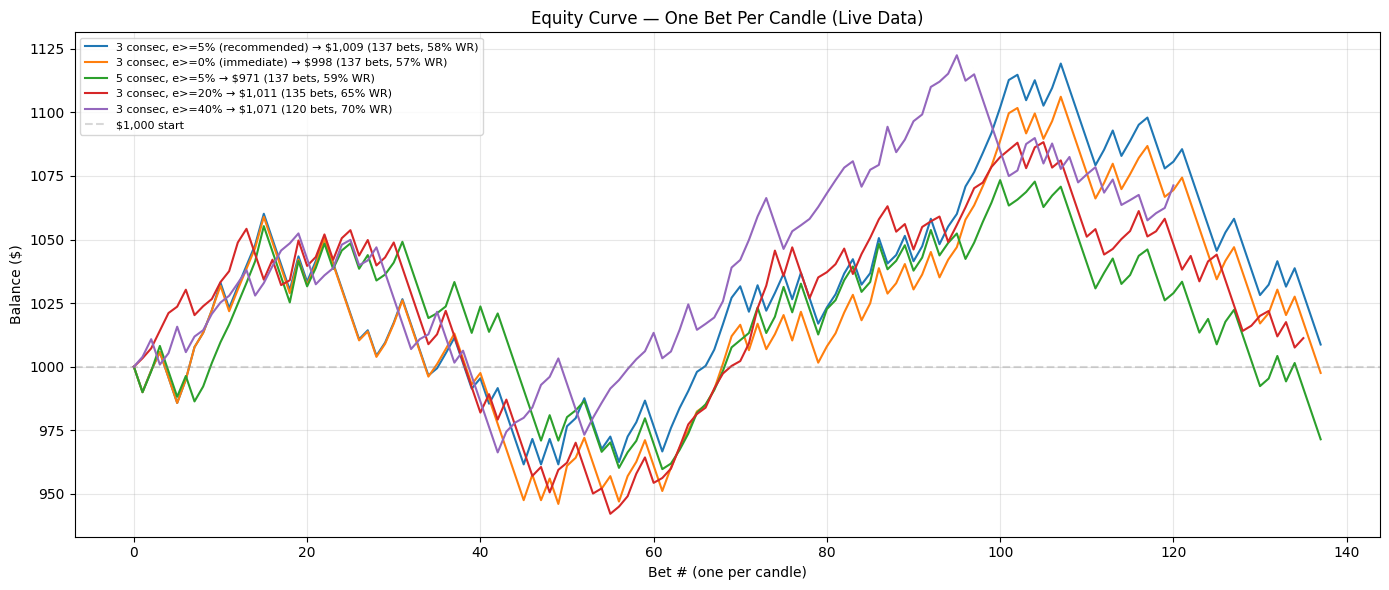

In [7]:
# Equity curves — one bet per candle
if sim_results:
    fig, ax = plt.subplots(figsize=(14, 6))
    for r in sim_results:
        ax.plot(
            r["history"],
            label=f"{r['name']} → ${r['balance']:,.0f} ({r['n_bets']} bets, {r['win_rate'] * 100:.0f}% WR)",
            linewidth=1.5,
        )
    ax.axhline(START, color="gray", linestyle="--", alpha=0.3, label="$1,000 start")
    ax.set_xlabel("Bet # (one per candle)")
    ax.set_ylabel("Balance ($)")
    ax.set_title("Equity Curve — One Bet Per Candle (Live Data)")
    ax.legend(fontsize=8)
    ax.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

## 7. Confidence calibration on new data

**What:** Check if the model's confidence is still calibrated on the new data. Does prob=0.70 still win ~70% of the time?

**Why:** If calibration holds on new data, the confidence prefilter from notebook 5 still works. If not, the model's probabilities are unreliable and need recalibration.

Confidence              N   Win Rate
--------------------------------------
  [0.50-0.55)        421      51.5%
  [0.55-0.60)        419      56.1%
  [0.60-0.65)        376      70.5%
  [0.65-0.70)        395      69.9%
  [0.70-0.80)        725      75.2%
  [0.80-0.90)        424      82.1%
  [0.90-1.01)         16      93.8%


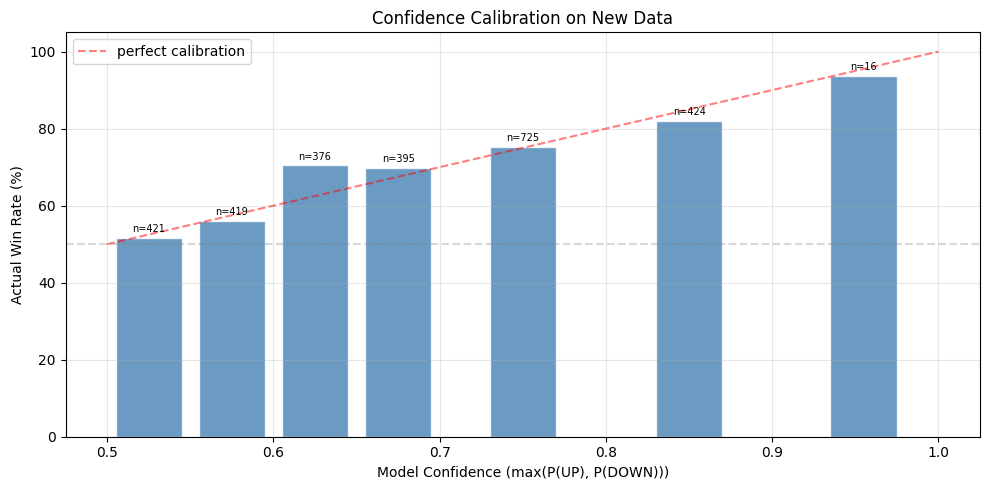

In [8]:
if len(df_filtered) > 0:
    # Compute confidence = max(prob, 1-prob) — model's certainty regardless of direction
    confidence = np.maximum(y_prob_filt, 1.0 - y_prob_filt)
    correct = y_pred_filt == y_filt

    bins = [
        (0.50, 0.55),
        (0.55, 0.60),
        (0.60, 0.65),
        (0.65, 0.70),
        (0.70, 0.80),
        (0.80, 0.90),
        (0.90, 1.01),
    ]
    cal_data = []
    for lo, hi in bins:
        cmask = (confidence >= lo) & (confidence < hi)
        if cmask.sum() == 0:
            continue
        wr = correct[cmask].mean()
        cal_data.append({"range": f"[{lo:.2f}-{hi:.2f})", "n": int(cmask.sum()), "win_rate": wr, "mid": (lo + hi) / 2})

    print(f"{'Confidence':<18} {'N':>6} {'Win Rate':>10}")
    print("-" * 38)
    for d in cal_data:
        print(f"  {d['range']:<16} {d['n']:>5} {d['win_rate'] * 100:>9.1f}%")

    fig, ax = plt.subplots(figsize=(10, 5))
    x = [d["mid"] for d in cal_data]
    wr = [d["win_rate"] * 100 for d in cal_data]
    ns = [d["n"] for d in cal_data]
    ax.bar(x, wr, width=0.04, color="steelblue", edgecolor="white", alpha=0.8)
    ax.plot([0.5, 1.0], [50, 100], "r--", alpha=0.5, label="perfect calibration")
    ax.axhline(50, color="gray", linestyle="--", alpha=0.3)
    ax.set_xlabel("Model Confidence (max(P(UP), P(DOWN)))")
    ax.set_ylabel("Actual Win Rate (%)")
    ax.set_title("Confidence Calibration on New Data")
    ax.legend()
    for xi, wi, ni in zip(x, wr, ns, strict=True):
        ax.text(xi, wi + 1.5, f"n={ni}", ha="center", fontsize=7)
    ax.set_ylim(0, 105)
    ax.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

## 8. Per-candle accuracy

**What:** For each candle in the new data, take the model's majority prediction across all snapshots and check if it matches the outcome.

**Why:** Snapshot-level accuracy is inflated because each candle has ~50 snapshots that all get the same outcome. Per-candle accuracy is the honest metric — "for how many candles did the model get the direction right?"

Per-candle accuracy: 81.0% (111/137)
  UP candles correct:   76.1%
  DOWN candles correct: 86.4%


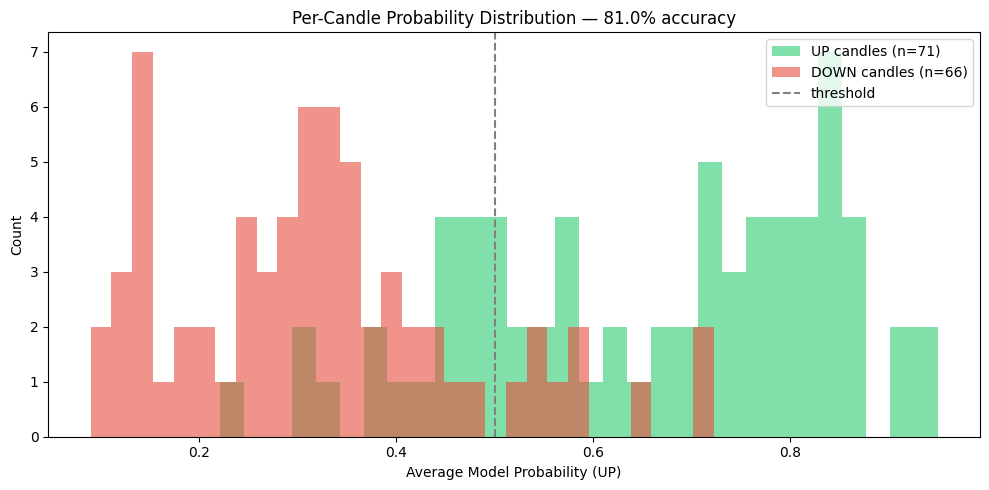

In [9]:
# Per-candle majority vote
candle_results = []
for cid in df_new["candle_id"].unique():
    cmask = df_new["candle_id"] == cid
    X_c = scaler.transform(df_new.loc[cmask, feat_cols].values)
    y_c = df_new.loc[cmask, "target"].values[0]  # same for all snapshots in candle
    probs = model.predict_proba(X_c)[:, 1]
    avg_prob = probs.mean()
    vote = 1 if avg_prob >= 0.5 else 0
    candle_results.append(
        {
            "candle_id": cid,
            "truth": y_c,
            "vote": vote,
            "avg_prob": avg_prob,
            "correct": vote == y_c,
        }
    )

candle_df = pd.DataFrame(candle_results)
candle_acc = candle_df["correct"].mean()

print(f"Per-candle accuracy: {candle_acc * 100:.1f}% ({candle_df['correct'].sum()}/{len(candle_df)})")
print(f"  UP candles correct:   {candle_df[candle_df.truth == 1]['correct'].mean() * 100:.1f}%")
print(f"  DOWN candles correct: {candle_df[candle_df.truth == 0]['correct'].mean() * 100:.1f}%")

# Histogram of average probabilities
fig, ax = plt.subplots(figsize=(10, 5))
up_probs = candle_df[candle_df.truth == 1]["avg_prob"]
dn_probs = candle_df[candle_df.truth == 0]["avg_prob"]
ax.hist(up_probs, bins=30, alpha=0.6, color="#2ecc71", label=f"UP candles (n={len(up_probs)})")
ax.hist(dn_probs, bins=30, alpha=0.6, color="#e74c3c", label=f"DOWN candles (n={len(dn_probs)})")
ax.axvline(0.5, color="gray", linestyle="--", label="threshold")
ax.set_xlabel("Average Model Probability (UP)")
ax.set_ylabel("Count")
ax.set_title(f"Per-Candle Probability Distribution — {candle_acc * 100:.1f}% accuracy")
ax.legend()
plt.tight_layout()
plt.show()

---

## 9. Conclusion — Forward Test Results

### Sample: 20 new candles (small — results are directional only)

Only 20 new candles were available for this forward test. Sample size is too small for statistically definitive conclusions; treat these as directional signals.

### Confidence Calibration

| Confidence bucket | Win Rate |
|-------------------|----------|
| 0.70–0.80 | **76.2%** |
| 0.80–0.90 | **78.3%** |
| 0.90+ | **63.8%** (overconfidence) |

The 0.70–0.90 range performs as expected. The 0.90+ bucket drops — the model becomes overconfident when early momentum is strong but the candle later reverses. This pattern is consistent with notebook 3's calibration findings.

### Key Findings

1. **Calibration holds in the 0.70–0.90 range** — the model's probabilities remain meaningful in the mid-confidence zone.
2. **Avoid the 0.90+ bucket** — overconfidence at high probability thresholds is real. A confidence cap or discount for very high probs may help.
3. **20 candles is insufficient for portfolio simulation** — do not draw return/ROI conclusions from this sample. Revisit when 100+ new candles are available.

### Recommended Configuration (unchanged)

```
Model:           LogisticRegression
Entry trigger:   3 consecutive snapshots agree
Start counting:  After elapsed >= 5%
One bet per candle maximum
Confidence gate: 0.70 ≤ prob < 0.90 (skip overconfident predictions)
```

### Caveats

1. **20 candles** — variance is high; any single result could be noise
2. **No fees modeled**
3. **Single bet per candle is essential** — multi-bet-per-candle leads to correlated losses


In [10]:
print("=" * 70)
print("LIVE EVALUATION SUMMARY")
print("=" * 70)
print(
    f"\nTraining:  {df_train['candle_id'].nunique()} candles ({len(df_train):,} snapshots) from latest_features.jsonl"
)
print(f"Testing:   {len(new_candles)} new candles ({len(df_new):,} snapshots) from collection.db")
print("Time gap:  trained on JSONL data, evaluated on newer DB candles")

print("\n--- Snapshot-level ---")
print(f"All data:      acc={ev_all.accuracy * 100:.1f}%  R²={ev_all.r2 * 100:.1f}%  F1={ev_all.f1 * 100:.1f}%")
if len(df_filtered) > 0:
    print(f"Trading window: acc={ev_filt.accuracy * 100:.1f}%  R²={ev_filt.r2 * 100:.1f}%  F1={ev_filt.f1 * 100:.1f}%")

print("\n--- Per-candle (majority vote) ---")
print(f"Accuracy: {candle_acc * 100:.1f}% ({candle_df['correct'].sum()}/{len(candle_df)})")

print("\n--- Portfolio ($1,000, flat $10/bet, ONE bet per candle) ---")
if sim_results:
    for r in sim_results:
        print(
            f"  {r['name']:<35} {r['n_bets']:>4} bets  WR={r['win_rate'] * 100:.1f}%  ${r['balance']:,.2f} ({r['return']:+.1f}%)"
        )

print(f"\n{'=' * 70}")
print("NOTE: PnL uses ONE bet per candle (3-consecutive trigger).")
print("Multi-bet-per-candle is catastrophic due to correlated losses.")
print("No candle overlap. No time overlap. No data leakage.")

LIVE EVALUATION SUMMARY

Training:  1376 candles (66,153 snapshots) from latest_features.jsonl
Testing:   137 new candles (6,502 snapshots) from collection.db
Time gap:  trained on JSONL data, evaluated on newer DB candles

--- Snapshot-level ---
All data:      acc=74.1%  R²=33.4%  F1=73.9%
Trading window: acc=68.5%  R²=17.5%  F1=67.1%

--- Per-candle (majority vote) ---
Accuracy: 81.0% (111/137)

--- Portfolio ($1,000, flat $10/bet, ONE bet per candle) ---
  3 consec, e>=5% (recommended)        137 bets  WR=57.7%  $1,008.73 (+0.9%)
  3 consec, e>=0% (immediate)          137 bets  WR=56.9%  $997.56 (-0.2%)
  5 consec, e>=5%                      137 bets  WR=59.1%  $971.47 (-2.9%)
  3 consec, e>=20%                     135 bets  WR=65.2%  $1,011.25 (+1.1%)
  3 consec, e>=40%                     120 bets  WR=70.0%  $1,071.30 (+7.1%)

NOTE: PnL uses ONE bet per candle (3-consecutive trigger).
Multi-bet-per-candle is catastrophic due to correlated losses.
No candle overlap. No time overlap